Full dataset : 2,062,185 rows
Working subset: 10,000 rows


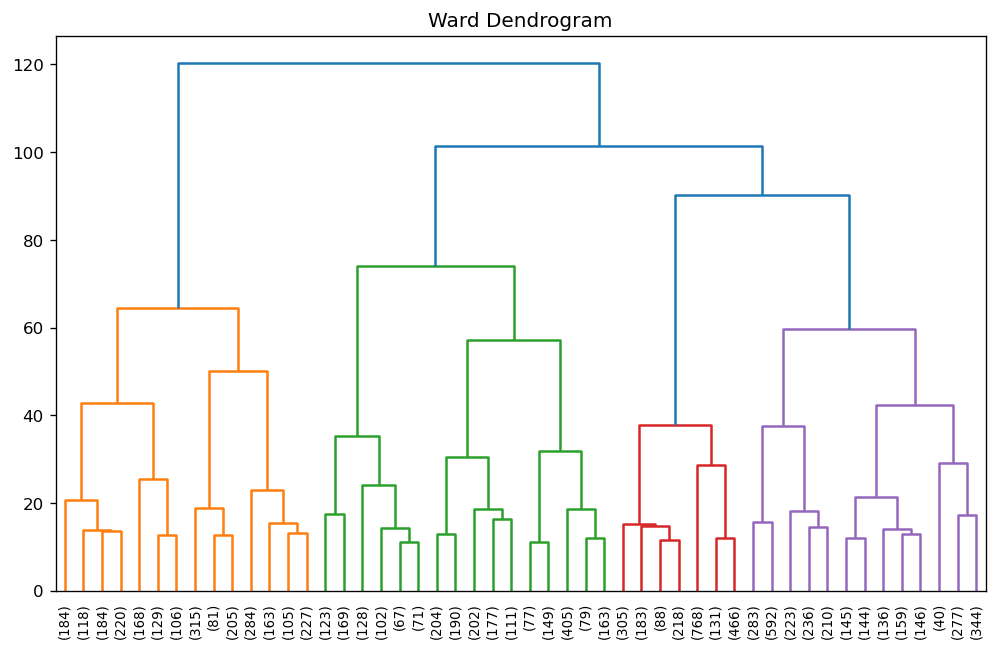

In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import haversine_distances
from sklearn.metrics import silhouette_score, davies_bouldin_score

# -----------------------
# Load Data
# -----------------------
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
DATA_PATH = "../Data/raw/merged_trip_emissions_coordinates.csv"

# Sample for speed
df_full = pd.read_csv(DATA_PATH, low_memory=False)
SUBSET_N = 10000

# -----------------------
# Preprocessing
# -----------------------

def preprocess(df):
    df = df.copy()

    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
    df["pickup_lat"] = pd.to_numeric(df["pickup_lat"], errors="coerce")
    df["pickup_lon"] = pd.to_numeric(df["pickup_lon"], errors="coerce")
    df["trip_miles"] = pd.to_numeric(df["trip_miles"], errors="coerce")
    df["co2_total_g"] = pd.to_numeric(df["co2_total_g"], errors="coerce")
    df["trip_time"] = pd.to_numeric(df["trip_time"], errors="coerce")

    df = df.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])

    print(f"Full dataset : {len(df_full):,} rows")
    print(f"Working subset: {len(df):,} rows")

    # Time features
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

    return df

df_train = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE))

# -----------------------
# Feature Scaling
# -----------------------
features = ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[features])

# -----------------------
# Clustering (Ward)
# -----------------------
clus = hierarchy.linkage(X_train, method="ward")

plt.figure(figsize=(10, 6))
hierarchy.dendrogram(clus, truncate_mode="lastp", p=50)
plt.title("Ward Dendrogram")
plt.show()


In [ ]:
# Find optimal cut height

print(f"Max linkage distance : {clus[:, 2].max():.2f}")
print(f"Min linkage distance : {clus[:, 2].min():.4f}")
print(f"75th percentile      : {np.percentile(clus[:, 2], 75):.2f}")
print(f"90th percentile      : {clus[:, 2][int(len(clus)*0.90):][:5]}")

# Look at the last 20 merge distances (these are the meaningful ones)
print("\nTop 20 merge distances:")
print(np.sort(clus[:, 2])[-20:][::-1].round(2))


heights = np.sort(clus[:, 2])[-20:]  # top 20 largest merges

silhouettes = []
dbi_scores  = []
num_clusters = []

for h in heights:
    labels = fcluster(clus, t=h, criterion='distance')
    
    k = len(set(labels))
    num_clusters.append(k)
    
    # skip invalid cases
    if k <= 1 or k >= len(X_train):
        silhouettes.append(np.nan)
        dbi_scores.append(np.nan)
        continue
    
    silhouettes.append(
        silhouette_score(X_train, labels, sample_size=min(5000, len(X_train)))
    )
    dbi_scores.append(
        davies_bouldin_score(X_train, labels)
    )

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(heights, num_clusters, marker="o")
axes[0].set_title("Clusters vs Height")
axes[0].set_xlabel("Height"); axes[0].set_ylabel("# Clusters")

axes[1].plot(heights, silhouettes, marker="o")
axes[1].set_title("Silhouette vs Height (higher = better)")
axes[1].set_xlabel("Height"); axes[1].set_ylabel("Silhouette")
axes[2].plot(heights, dbi_scores, marker="o")
axes[2].set_title("DBI vs Height (lower = better)")
axes[2].set_xlabel("Height"); axes[2].set_ylabel("DBI")

plt.tight_layout()
plt.show()

# Best height based on silhouette
best_idx = np.nanargmax(silhouettes)
BEST_HEIGHT = heights[best_idx]
best_labels = fcluster(clus, t=BEST_HEIGHT, criterion='distance')

df_train["hier_cluster"] = best_labels

print(f"Best height = {BEST_HEIGHT:.3f}")
print(f"Clusters at best height = {num_clusters[best_idx]}")
print(f"Best silhouette = {silhouettes[best_idx]:.4f}")

pd.Series(best_labels).value_counts().describe()

Max linkage distance : 120.42
Min linkage distance : 0.0000
75th percentile      : 0.29
90th percentile      : [0.86278746 0.86303582 0.86484046 0.86685047 0.86707462]

Top 20 merge distances:
[120.42 101.48  90.12  74.06  64.5   59.6   57.18  50.    42.71  42.3
  37.78  37.55  35.19  31.76  30.5   29.03  28.57  25.39  23.97  22.85]


NameError: name 'X' is not defined

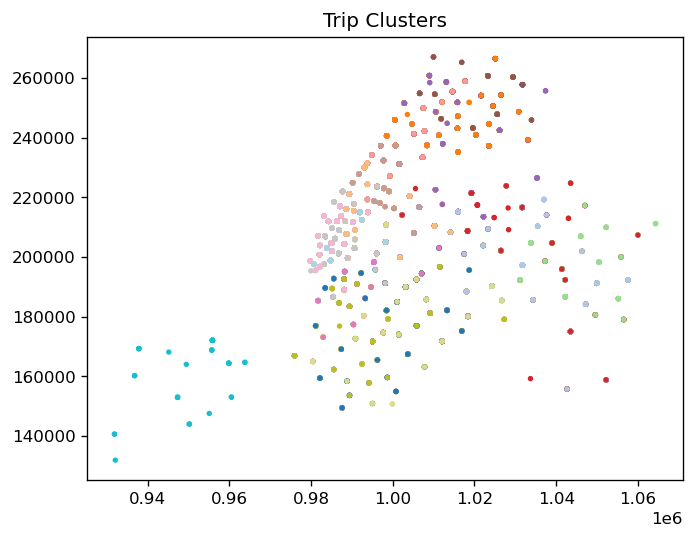

In [ ]:
plt.scatter(df_train["pickup_lon"], df_train["pickup_lat"], c=best_labels, s=5, cmap="tab20")
plt.title("Trip Clusters")
plt.show()

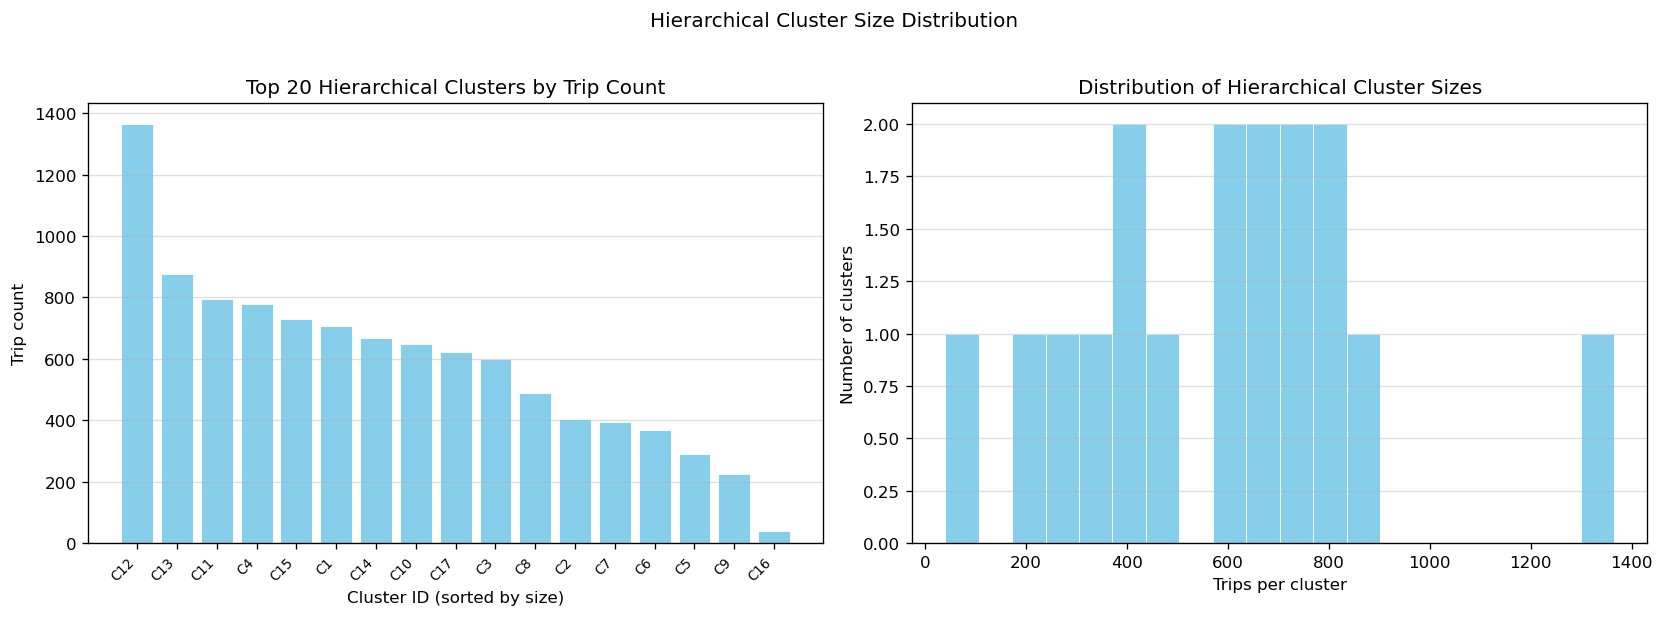

Median cluster size : 621 trips
Largest cluster     : 1365 trips
Smallest cluster    : 40 trips
Std dev of sizes    : 302.0  (lower = more balanced)


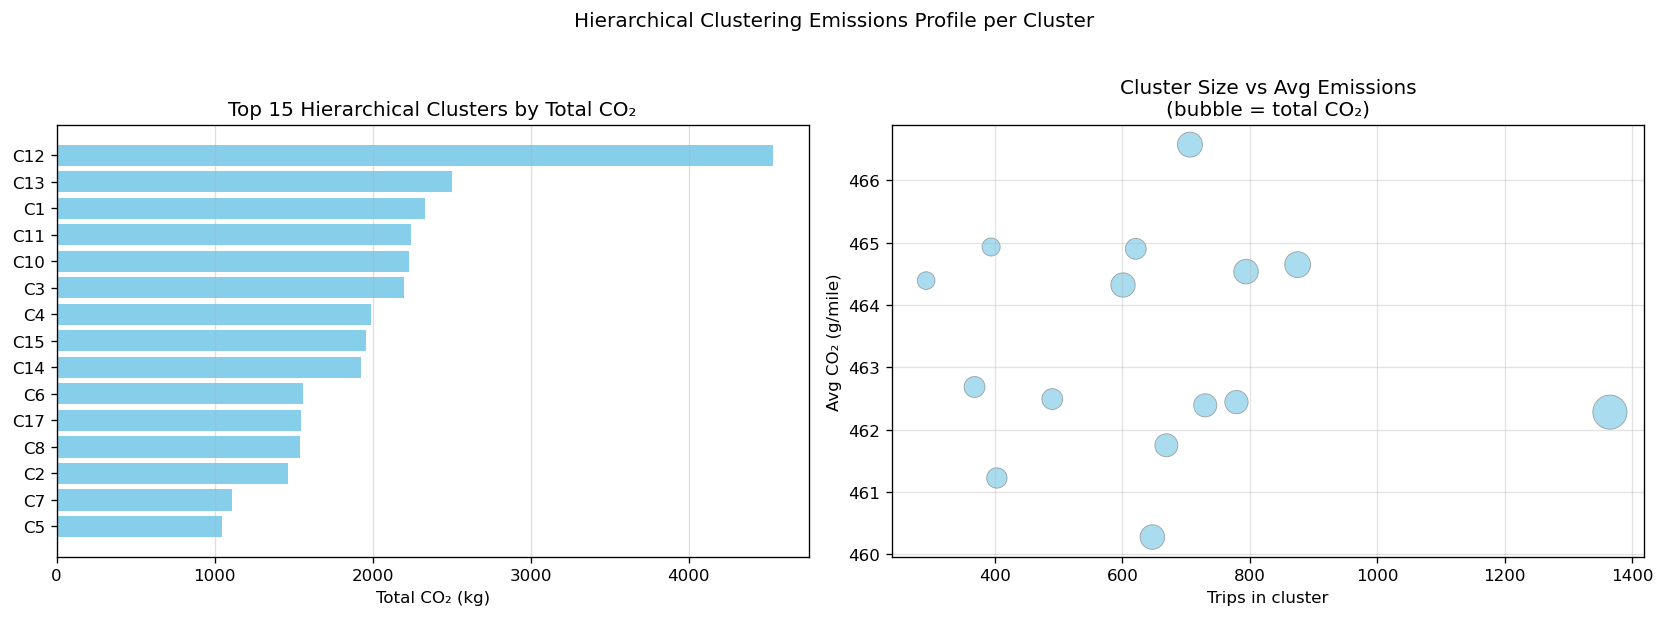


Top 5 highest-emission hierarchical clusters:
 hier_cluster  n_trips  avg_co2_g_mi  total_co2_kg  avg_trip_miles
           12     1365    462.281702   4533.149692        7.191157
           13      875    464.648542   2504.380013        6.124754
            1      706    466.573588   2329.157614        7.050195
           11      794    464.535837   2243.230271        6.095094
           10      647    460.278078   2232.727331        7.477116


In [ ]:
# Cluster Size Distributions and Emissions Profile
# -----------------------
# Cluster sizes
# -----------------------
cluster_sizes = (
    df_train.groupby("hier_cluster").size()
    .reset_index(name="n_trips")
    .sort_values("n_trips", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-20 clusters by size
top20 = cluster_sizes.head(20)
axes[0].bar(
    top20.index, 
    top20["n_trips"], 
    color="skyblue", 
    edgecolor="white", 
    linewidth=0.5
)
axes[0].set_xticks(top20.index)
axes[0].set_xticklabels([f"C{int(c)}" for c in top20["hier_cluster"]], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Cluster ID (sorted by size)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Top 20 Hierarchical Clusters by Trip Count")
axes[0].grid(axis="y", alpha=0.4)

# Histogram of all cluster sizes
axes[1].hist(cluster_sizes["n_trips"], bins=20, color="skyblue", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Trips per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Distribution of Hierarchical Cluster Sizes")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Hierarchical Cluster Size Distribution", y=1.02)
plt.tight_layout()
plt.show()

print(f"Median cluster size : {cluster_sizes['n_trips'].median():.0f} trips")
print(f"Largest cluster     : {cluster_sizes['n_trips'].max()} trips")
print(f"Smallest cluster    : {cluster_sizes['n_trips'].min()} trips")
print(f"Std dev of sizes    : {cluster_sizes['n_trips'].std():.1f}  (lower = more balanced)")

# -----------------------
# CO₂ emissions per cluster
# -----------------------
emissions_cluster = (
    df_train.groupby("hier_cluster")
    .agg(
        n_trips        = ("trip_miles", "count"),
        avg_co2_g_mi   = ("co2_total_g", lambda x: (x / df_train.loc[x.index, "trip_miles"]).mean()),
        total_co2_kg   = ("co2_total_g", lambda x: x.sum() / 1000),
        avg_trip_miles = ("trip_miles", "mean")
    )
    .reset_index()
    .sort_values("total_co2_kg", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 clusters by total CO2
axes[0].barh(
    [f"C{int(r['hier_cluster'])}" for _, r in emissions_cluster.iterrows()],
    emissions_cluster["total_co2_kg"], 
    color="skyblue"
)
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Top 15 Hierarchical Clusters by Total CO₂")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.4)

# Bubble plot: size vs avg emissions
axes[1].scatter(
    emissions_cluster["n_trips"], 
    emissions_cluster["avg_co2_g_mi"],
    s=emissions_cluster["total_co2_kg"] / emissions_cluster["total_co2_kg"].max() * 400 + 20,
    color="skyblue", alpha=0.7, edgecolors="grey", linewidth=0.5
)
axes[1].set_xlabel("Trips in cluster")
axes[1].set_ylabel("Avg CO₂ (g/mile)")
axes[1].set_title("Cluster Size vs Avg Emissions\n(bubble = total CO₂)")
axes[1].grid(alpha=0.35)

plt.suptitle("Hierarchical Clustering Emissions Profile per Cluster", y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 5 highest-emission hierarchical clusters:")
print(emissions_cluster[["hier_cluster","n_trips","avg_co2_g_mi","total_co2_kg","avg_trip_miles"]].head().to_string(index=False))

In [ ]:
# Save full labeled dataset
out_full = "../Data/generated/trips_hierarchical_labeled.csv"
df_train.to_csv(out_full, index=False)
print(f"\nSaved → {out_full}  ({len(df_train):,} rows)")


Saved → ../Data/generated/trips_hierarchical_labeled.csv  (10,000 rows)


## Hierarchical Model Validation 

Full dataset : 2,062,185 rows
Working subset: 10,000 rows


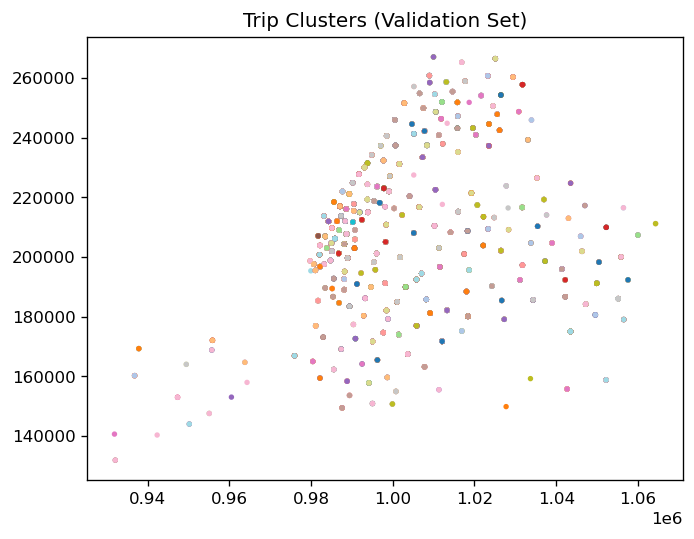

n_clusters: 17
silhouette: 0.2245
davies_bouldin: 1.093
cluster_size_std: 335.3


In [ ]:
RANDOM_STATE_VAL = 23
df_validate = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE_VAL))
X_val = scaler.transform(df_validate[features])
clus_val = hierarchy.linkage(X_val, method="ward")
labels_val = fcluster(clus_val, t=BEST_HEIGHT, criterion="distance")
df_validate["hier_cluster"] = labels_val

# Plot Trip Clusters
plt.scatter(df_validate["pickup_lon"], df_validate["pickup_lat"], c=best_labels, s=5, cmap="tab20")
plt.title("Trip Clusters (Validation Set)")
plt.show()

# Compute hierarchical cluster metrics
hier_n_clusters = df_validate["hier_cluster"].nunique()
mask_hier = df_validate["hier_cluster"] >= 0  # all rows are valid

sil_hier = silhouette_score(X_val, df_validate.loc[mask_hier, "hier_cluster"],
                             sample_size=min(5000, mask_hier.sum()), random_state=RANDOM_STATE)
dbi_hier = davies_bouldin_score(X_val, df_validate.loc[mask_hier, "hier_cluster"])
cluster_sizes_hier = df_validate.groupby("hier_cluster").size()

print(f"n_clusters: {hier_n_clusters}")
print(f"silhouette: {round(sil_hier, 4)}")
print(f"davies_bouldin: {round(dbi_hier, 4)}")
print(f"cluster_size_std: {round(cluster_sizes_hier.std(), 1)}")

### Trained Model Results

| Metric               | Value  |
|----------------------|--------|
| Number of Clusters   | 17     |
| Silhouette Score     | 0.2396 |
| Davies-Bouldin Index | 1.1100 |
| Cluster Size Std Dev | 302.0  |

### Validation Model Results

| Metric               | Value  |
|----------------------|--------|
| Number of Clusters   | 17     |
| Silhouette Score     | 0.2245 |
| Davies-Bouldin Index | 1.093  |
| Cluster Size Std Dev | 335.3  |

The trained and validation results are relatively consistent, with similar numbers of clusters and evaluation metrics. The silhouette scores are positive but modest, indicating moderate clustering structure. This is visible in the trip cluster plots, where there is moderate overlap of trip clusters. The Davies-Bouldin Index values are also comparable, suggesting similar cluster separation quality across datasets. The increase in cluster size standard deviation in the validation set (302 → 335.3) indicates slightly less balanced clusters, which is expected due to sampling variability. 
The results demonstrate that the hierarchical clustering model is stable and reasonably robust, though cluster separation could be improved.